In [1]:
import numpy as np
import matplotlib.pyplot as plt

from Inverter_model import Inverter_Controller
from scipy.integrate import solve_ivp

plt.rcParams.update({
        "font.weight": "bold",  # bold fonts
        "font.size":12,
        "lines.linewidth": 2,   # thick lines
        "grid.color": "0.5",    # gray gridlines
        "grid.linewidth": 0.5,  # thin gridlines
        "savefig.dpi": 300,     # higher resolution output.
        "axes.labelsize" : 15,
        'legend.labelspacing':0.95,
    })

In [2]:
pi = np.pi
Vnomi = 400
Pbasei = 3000
Vbasei = Vnomi*np.sqrt(2/3)
Ibasei = 2*(Pbasei/Vbasei) #vdid +vqiq = 2P
Zbasei = Vbasei/Ibasei

PLoadi = 3000*0.8;
QLoadi = 3000*0.6;
Inomi = Pbasei/(np.sqrt(3)*Vnomi)
RLi = PLoadi/(3*Inomi**2)
XLi = QLoadi/(3*Inomi**2)

Pbasei = 4000
Inomi = Pbasei/(np.sqrt(3)*Vnomi)
RL1i,XL1i = (Pbasei*0.8)/(3*Inomi**2), (Pbasei*0.6)/(3*Inomi**2)

m1i,m2i,n1i,n2i = np.array([5e-5,2e-5,3e-4,1e-4])

# Define Variables
#Inverter Variables
Lfi, Rfi, Cfi= 3.5E-3,0.1,50E-6
w0i,wfi = 2*np.pi*50, 4*np.pi
fsw=10e3;
Ts = 1/(fsw*50);
Tci=4/(2*pi*fsw);
wci=1/Tci;
Kpci=Lfi*wci;
Kici=Rfi*wci;
pm=50*pi/180;
wcv=1/Tci*(1-np.sin(pm))/(1+np.sin(pm));
wgc=np.sqrt(wcv*wci);
Kpvi=Cfi*wgc;
Kivi=Kpvi*wcv;
vdrefi, vqrefi = 400*np.sqrt(2/3),0

In [3]:
print(Kpvi,Kivi,Kpci,Kici)

0.2858615535240143 594.8498590345745 54.977871437821385 1570.7963267948967


##### Solving the non linear model to obtain the initial value for analysis

In [4]:
t0 = 0.0
t = 1
dt = 0.0001
t_eval = np.arange(t0,t,dt)
x0 = np.zeros(26)

In_sol0 = solve_ivp(Inverter_Controller,[t0,t],y0 = x0,t_eval=t_eval,args=(RLi,XLi,m1i,m2i,n1i,n2i,Kpci,Kici,Kpvi,Kivi))

t0 = 1
t = 2
dt = 0.0001
t_eval = np.arange(t0,t,dt)
x0 = In_sol0.y[:,-1]

In_sol1 = solve_ivp(Inverter_Controller,[t0,t],y0 = x0,t_eval=t_eval,args=(RL1i,XL1i,m1i,m2i,n1i,n2i,Kpci,Kici,Kpvi,Kivi))

sol = np.concatenate((In_sol0.y, In_sol1.y), axis=1)

t_eval = np.arange(0,t,dt)
pinv1sn,qinv1sn,delta1sn,ifd1sn,ifq1sn,vcd1sn,vcq1sn,iod1sn,ioq1sn,gammad1sn,gammaq1sn,zetad1sn,zetaq1sn,pinv2sn,qinv2sn,delta2sn,ifd2sn,ifq2sn,vcd2sn,vcq2sn,iod2sn,ioq2sn,gammad2sn,gammaq2sn,zetad2sn,zetaq2sn  = sol

In [5]:
#finding initial points of linearizaton
X0 = In_sol1.y.T[0]

#### Small signal analysis of parallel inverter
The general layout of an inverter model is shown below:

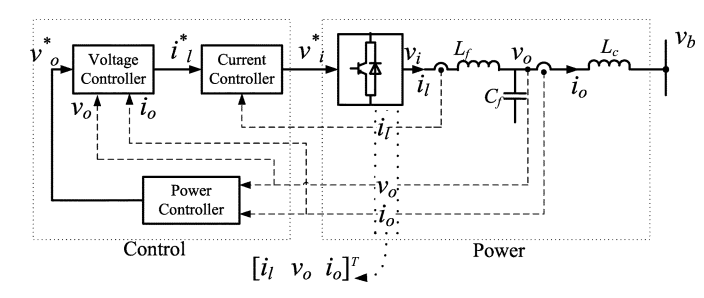




In [6]:
from Inverter_model import Linear_Inverter_Model

In [7]:
Am,Bm = Linear_Inverter_Model(RLi,XLi,m1i,m2i,n1i,n2i,Kpci,Kici,Kpci,Kivi,X0)

Eigen Values on steady state: 
  [-50.45010638+3.12988538e+02j -50.45010638-3.12988538e+02j
  -6.18097202+1.23276829e+01j  -6.18097202-1.23276829e+01j
 -15.97148162+0.00000000e+00j -12.56636815+0.00000000e+00j
 -12.5715633 +0.00000000e+00j -10.81933811+0.00000000e+00j
 -10.82023152+0.00000000e+00j -10.82000258+0.00000000e+00j
 -10.81982069+0.00000000e+00j -28.57142857+0.00000000e+00j
 -28.57142857+0.00000000e+00j -28.57142857+8.19434007e-13j
 -28.57142857-8.19434007e-13j   0.        +0.00000000e+00j]


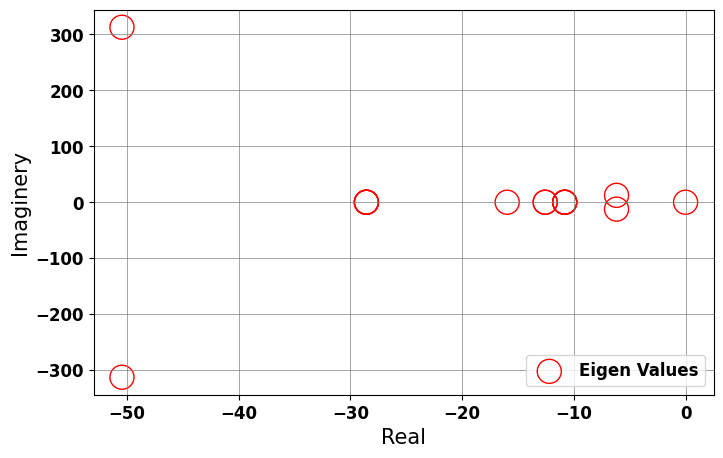

In [8]:
eigv = np.linalg.eigvals(Am)
eigv=eigv[eigv.real>-500]
print('Eigen Values on steady state: \n ', eigv)

fig, ax = plt.subplots(figsize = (8,5))
ax.scatter(eigv.real,eigv.imag,s=300,facecolors = "none",edgecolors = 'r',label = "Eigen Values")
ax.set_xlabel("Real")
ax.set_ylabel("Imaginery")
ax.grid()
ax.legend(loc = 'lower right')
#plt.savefig('Images/eigen_val.jpg',dpi = 300, bbox_inches='tight')

In [9]:
np.array([-50.42860306+3.13062201e+02j, -50.42860306-3.13062201e+02j,
        -6.20323615+1.02041662e+01j,  -6.20323615-1.02041662e+01j,
       -15.97033462+0.00000000e+00j, -12.56636537+0.00000000e+00j,
       -12.57243446+0.00000000e+00j, -10.8192222 +0.00000000e+00j,
       -10.82027837+0.00000000e+00j, -10.81998727+0.00000000e+00j,
       -10.81983134+0.00000000e+00j, -28.57142857+5.57461851e-12j,
       -28.57142857-5.57461851e-12j, -28.57142857+0.00000000e+00j,
       -28.57142857+0.00000000e+00j,   0.        +0.00000000e+00j])

array([-50.42860306+3.13062201e+02j, -50.42860306-3.13062201e+02j,
        -6.20323615+1.02041662e+01j,  -6.20323615-1.02041662e+01j,
       -15.97033462+0.00000000e+00j, -12.56636537+0.00000000e+00j,
       -12.57243446+0.00000000e+00j, -10.8192222 +0.00000000e+00j,
       -10.82027837+0.00000000e+00j, -10.81998727+0.00000000e+00j,
       -10.81983134+0.00000000e+00j, -28.57142857+5.57461851e-12j,
       -28.57142857-5.57461851e-12j, -28.57142857+0.00000000e+00j,
       -28.57142857+0.00000000e+00j,   0.        +0.00000000e+00j])

In [10]:
t0 = 0
t = 1
dt = 0.0001
t_eval = np.arange(t0,t,dt)
x0 = np.zeros(Am.shape[0])
inp = np.array([vdrefi,vqrefi,w0i])
Am,Bm = Linear_Inverter_Model(RLi,XLi,m1i,m2i,n1i,n2i,Kpci,Kici,Kpci,Kivi,X0)
def o_model(t,x):
    return np.matmul(Am,x) + np.matmul(Bm,inp)

solL0 = solve_ivp(o_model,[t0,t],y0 = x0,t_eval=t_eval)

x0 = solL0.y.T[-1]
Am,Bm = Linear_Inverter_Model(RL1i,XL1i,m1i,m2i,n1i,n2i,Kpci,Kici,Kpci,Kivi,X0)
t0 = 1
t = 2
dt = 0.0001
t_eval = np.arange(t0,t,dt)

solL1 = solve_ivp(o_model,[t0,t],y0 = x0,t_eval=t_eval)

sol = np.concatenate((solL0.y, solL1.y), axis=1)

t_eval = np.arange(0,t,dt)
pinv1s,qinv1s,delta1s,ifd1s,ifq1s,vcd1s,vcq1s,iod1s,ioq1s,gammad1s,gammaq1s,zetad1s,zetaq1s,pinv2s,qinv2s,delta2s,ifd2s,ifq2s,vcd2s,vcq2s,iod2s,ioq2s,gammad2s,gammaq2s,zetad2s,zetaq2s  = sol

In [11]:
w1s = (w0i - m1i*pinv1s)/(2*np.pi)
w2s = (w0i - m2i*pinv2s)/(2*np.pi)
w1sn = (w0i - m1i*pinv1sn)/(2*np.pi)
w2sn = (w0i - m2i*pinv2sn)/(2*np.pi)

v1s = vdrefi - n1i*qinv1s
v2s = vdrefi - n2i*qinv2s
v1sn = vdrefi - n1i*qinv1sn
v2sn = vdrefi - n2i*qinv2sn

In [12]:
# Read from simulink
import pandas as pd
tsim,p1sim,p2sim,w1sim,w2sim,q1sim,q2sim,v1sim,v2sim,va,vb,vc,ia,ib,ic = pd.read_csv('simu_data.csv').values.T

In [13]:
#Writing the data in a file
d = {'tsim': tsim, 'p1sim': p1sim,'p2sim':p2sim,'w1sim':w1sim,'w2sim':w2sim, 'q1sim':q1sim, 'q2sim':q2sim,
     'v1sim':v1sim,'v2sim':v2sim}
NoVimp = pd.DataFrame(d)

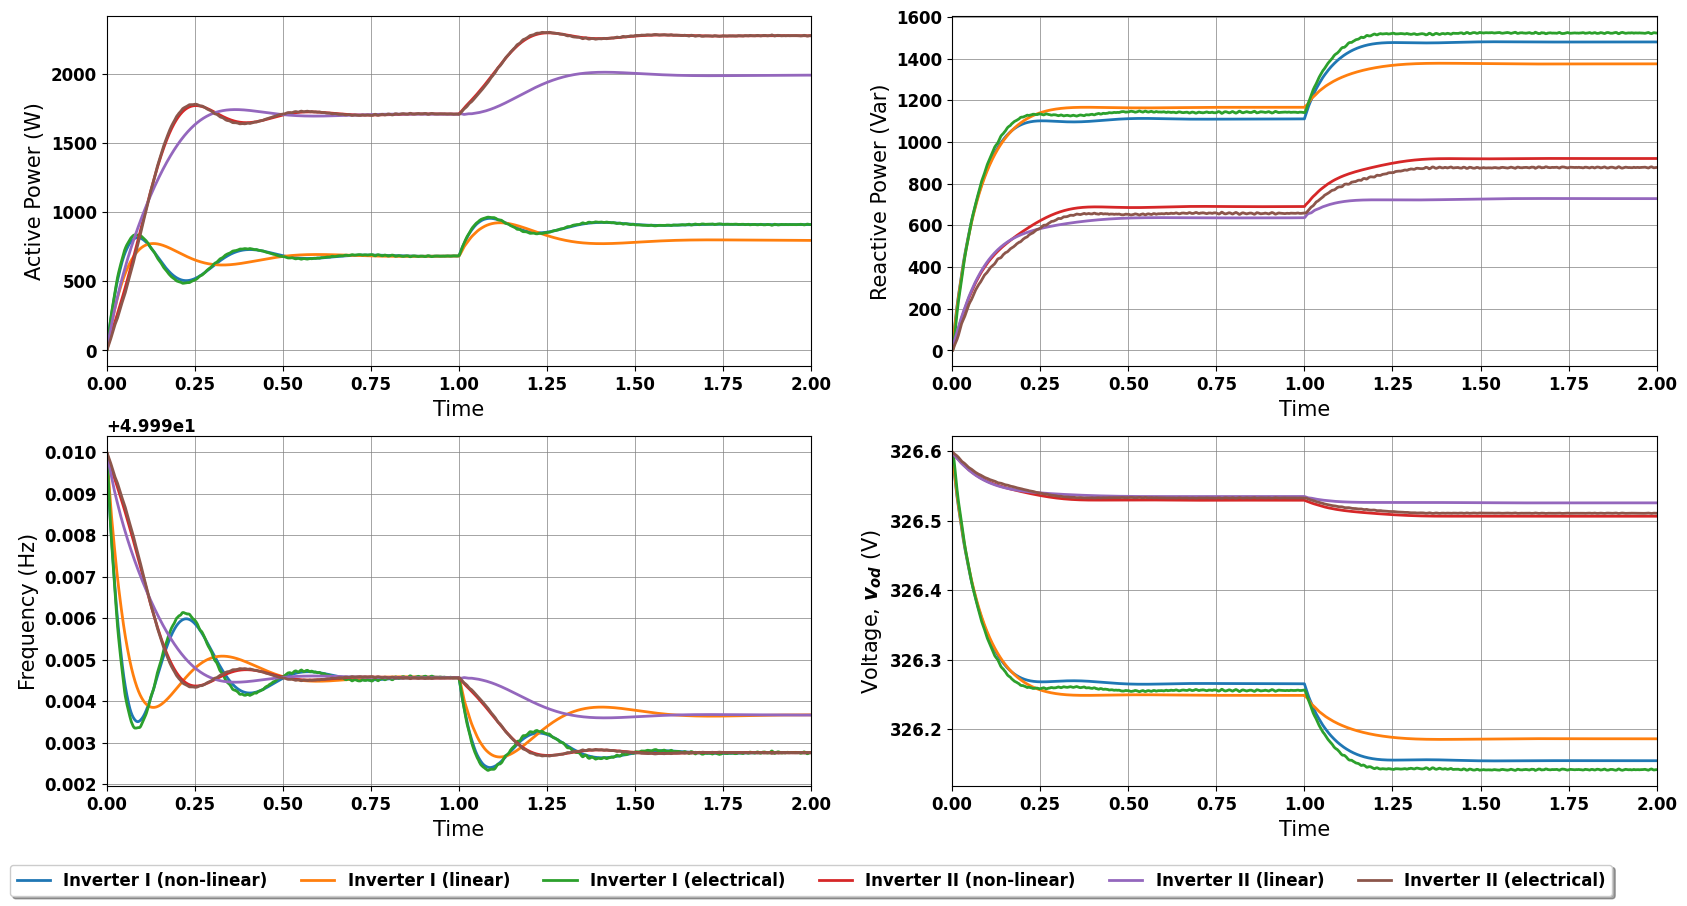

In [14]:
xlim = [0.0,2]
fig, axs = plt.subplots(2, 2,figsize = (20,10))
axs[0, 0].plot(t_eval,pinv1sn)
axs[0, 0].plot(t_eval,pinv1s)
axs[0, 0].plot(tsim,p1sim)
axs[0, 0].plot(t_eval,pinv2sn)
axs[0, 0].plot(t_eval,pinv2s)
axs[0, 0].plot(tsim,p2sim)
axs[0, 0].grid()
axs[0, 0].set_xlim(xlim)
axs[0, 0].set_xlabel("Time")
axs[0, 0].set_ylabel("Active Power (W)")


axs[0,1].plot(t_eval,qinv1sn)
axs[0,1].plot(t_eval,qinv1s)
axs[0,1].plot(tsim,q1sim)
axs[0,1].plot(t_eval,qinv2sn)
axs[0,1].plot(t_eval,qinv2s)
axs[0,1].plot(tsim,q2sim)
axs[0,1].grid()
axs[0,1].set_xlim(xlim)
axs[0,1].set_xlabel("Time")
axs[0,1].set_ylabel("Reactive Power (Var)")

axs[1,0].plot(t_eval,w1sn,label = 'Inverter I (non-linear)')
axs[1,0].plot(t_eval,w1s, label = 'Inverter I (linear)')
axs[1,0].plot(tsim,w1sim, label = 'Inverter I (electrical)')
axs[1,0].plot(t_eval,w2sn,label = 'Inverter II (non-linear)')
axs[1,0].plot(t_eval,w2s, label = 'Inverter II (linear)')
axs[1,0].plot(tsim,w2sim, label = 'Inverter II (electrical)')
axs[1,0].grid()
axs[1,0].set_xlim(xlim)
axs[1,0].set_xlabel("Time")
axs[1,0].set_ylabel("Frequency (Hz)")
axs[1,0].legend(loc='upper center', bbox_to_anchor=(1, -0.2),fancybox=True, shadow=True, ncol=6)

axs[1,1].plot(t_eval,v1sn)
axs[1,1].plot(t_eval,v1s)
axs[1,1].plot(tsim,v1sim)
axs[1,1].plot(t_eval,v2sn)
axs[1,1].plot(t_eval,v2s)
axs[1,1].plot(tsim,v2sim)
axs[1,1].grid()
axs[1,1].set_xlim(xlim)
axs[1,1].set_xlabel("Time")
axs[1,1].set_ylabel("Voltage, $v_{od}$ (V)")
plt.savefig('Without_Virtual_Impedance.jpg',dpi = 300, bbox_inches='tight')

In [15]:
~!@

SyntaxError: invalid syntax (798529566.py, line 1)

#### Frequency and Time Domain Analysis

In [ ]:
wrange = np.linspace(0.1,10000,1000)

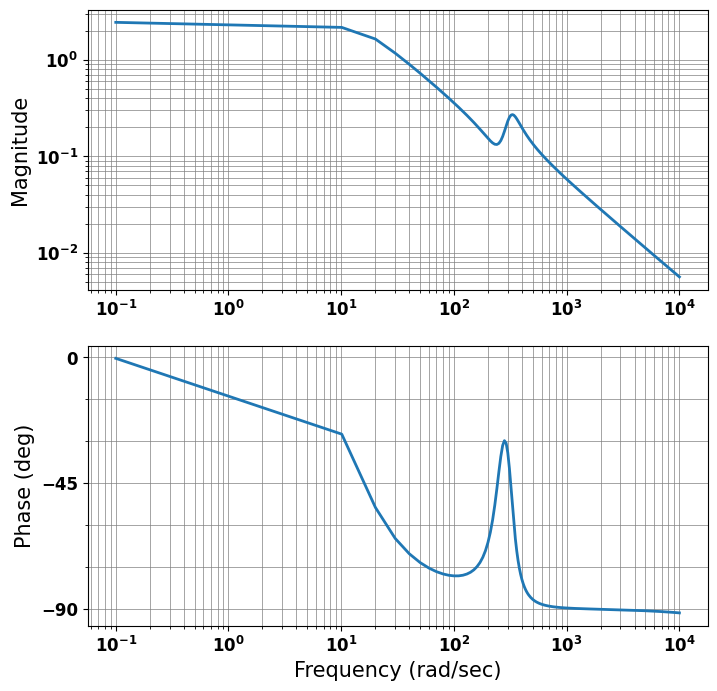

In [ ]:
import control as cm

Ip = np.array([vdrefi])
A = Am
B = Bm[:,0]#np.matmul(Bm,Ip)
C = np.zeros([Am.shape[0]])
C[0]=1
D = np.array([0])
sys = cm.ss(A,B,C,D)
fig,ax = plt.subplots(figsize = (8,8))
mag, phase, w = cm.bode(sys,omega=wrange)

In [ ]:
dat = {'phase': phase, 'w': w,'mag':mag}
freq_data = pd.DataFrame(d)
freq_data.to_csv('freq_data_noV.csv')

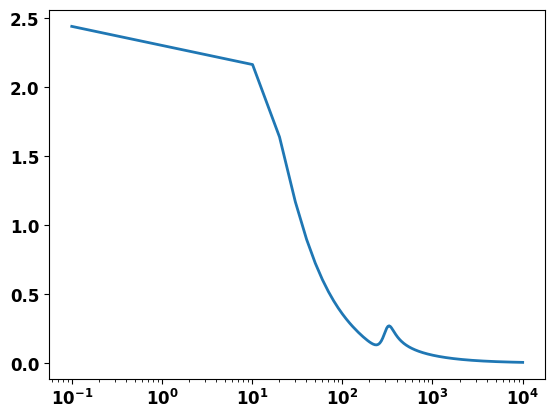

In [ ]:
plt.semilogx(w,mag)

##### Modelling Power Controller:
$$p = 3/2(v_{od}i_{od} + v_{oq}i_{oq})$$
$$q = 3/2(v_{od}i_{oq} - v_{oq}i_{od})$$

$$P = \frac{\omega_c}{s+\omega_c}\times p,Q = \frac{\omega_c}{s+\omega_c} \times q$$

$$ \omega = \omega_0 - P \times m_1 $$ 
$$ \delta =  \int  (\omega - \omega_r)dt $$

In [ ]:
vod,voq,iod,ioq,ild,ilq = symbols(['v_od','v_oq','i_od','i_oq','i_ld','i_lq'])
P,Q,m,n,delta,vdref,vqref = symbols(['P','Q','m','n','delta','v_{dref}','v_{qref}'])
w,w0,wr,wc = symbols(['omega','omega_0','omega_r','omega_c'])

p = (3/2)*(vod*iod + voq*ioq)
q = (3/2)*((vod*ioq - voq*iod))

P_dot = -wc*(P + p)
Q_dot = -wc*(Q + q)
w  = w0 - P * m
delta_dot = w-wr

deriv = Matrix([delta_dot,P_dot,Q_dot])
state = Matrix([delta,P,Q])
input_v = Matrix([ild,ilq,vod,voq,iod,ioq])
d1 = Matrix([wr])
o1 = Matrix([w])
vod = vdref-n*Q
o2 = Matrix([vod,voq])
Ap,Bp,Bpw,Cpw,Cpv = get_matrix(deriv,state),get_matrix(deriv,input_v),get_matrix(deriv,d1),get_matrix(o1,state),get_matrix(o2,state)

#### Voltage controller
$$\frac{d\phi_d}{dt} = v_{dref} - v_{od}, \frac{d\phi_q}{dt} = v_{qref} - v_{oq}$$

$$i_{ldref} = $$

In [ ]:
phid,phiq = symbols(['phi_d','phi_q'])
F,Cf,Kpv,Kiv,w = symbols(['F','C_f','K_pv','K_iv','omega'])
vod,voq,iod,ioq,ild,ilq = symbols(['v_od','v_oq','i_od','i_oq','i_ld','i_lq'])

ildref = F*iod - w*Cf*voq + Kpv*(vdref - vod) + Kiv*phid
ilqref = F*ioq + w*Cf*vod + Kpv*(vqref - voq) + Kiv*phiq

phid_dot = vdref - vod
phiq_dot = vqref - voq

deriv = Matrix([phid_dot,phiq_dot])
state = Matrix([phid,phiq])
input_v = Matrix([ild,ilq,vod,voq,iod,ioq])
d1 = Matrix([vdref,vqref])
out = Matrix([ildref,ilqref])

Av,Bv1,Bv2 = get_matrix(deriv,state),get_matrix(deriv,d1),get_matrix(deriv,input_v)
Cv,Dv1,Dv2 = get_matrix(out,state),get_matrix(out,d1),get_matrix(out,input_v)

In [ ]:
gammad,gammaq = symbols(['gamma_d','gamma_q'])
Lf,Kpc,Kic,w = symbols(['L_f','K_pc','K_ic','omega'])
vod,voq,iod,ioq,ild,ilq = symbols(['v_od','v_oq','i_od','i_oq','i_ld','i_lq'])
ildref,ilqref = symbols(['i_ldref','i_lqref'])

vidref = -w*Lf*ilq + Kpc*(ildref - ild) + Kic*gammad
viqref = w*Lf*ild + Kpc*(ilqref - ilq) + Kic*gammaq

gammad_dot = ildref - ild
gammaq_dot = ilqref - ilq

deriv = Matrix([gammad_dot,gammaq_dot])
state = Matrix([gammad,gammaq])
input_v = Matrix([ild,ilq,vod,voq,iod,ioq])
d1 = Matrix([ildref,ilqref])
out = Matrix([vidref,viqref])

Ac,Bc1,Bc2 = get_matrix(deriv,state),get_matrix(deriv,d1),get_matrix(deriv,input_v)
Cc,Dc1,Dc2 = get_matrix(out,state),get_matrix(out,d1),get_matrix(out,input_v)

In [ ]:
#LCL filter model
Vdc,Tinv,Kinv = symbols(['V_dc','T_inv','K_inv'])
Rf,Lf,Cf,Rc,Lc,w = symbols(['R_f','L_f','C_f','R_c','L_c','omega'])
vod,voq,iod,ioq,ild,ilq,vbd,vbq = symbols(['v_od','v_oq','i_od','i_oq','i_ld','i_lq','v_bd','v_bq'])
dd,dq = symbols(['d_d','d_q'])
vid,viq = symbols(['v_id','v_iq'])

ild_dot = (-Rf/Lf)*ild + w*ilq + (vid - vod)/Lf
ilq_dot = -w*ild + (-Rf/Lf)*ilq + (viq - voq)/Lf
vod_dot = w*voq + (ild - iod)/Cf
voq_dot = -w*vod + (ilq - ioq)/Cf
iod_dot = (-Rc/Lc)*iod + w*ioq + (vod - vbd)/Lc
ioq_dot = -w*iod + (-Rc/Lc)*ioq + (voq - vbq)/Lc

deriv = Matrix([ild_dot,ilq_dot,vod_dot,voq_dot,iod_dot,ioq_dot])
state = Matrix([ild,ilq,vod,voq,iod,ioq])
inp1 = Matrix([vid,viq])
inp2 = Matrix([vbd,vbq])
inp3 = Matrix([w])
Alcl,Blcl1,Blcl2,Blcl3 = get_matrix(deriv,state),get_matrix(deriv,inp1),get_matrix(deriv,inp2),get_matrix(deriv,inp3)

In [ ]:
ioD,ioQ,vbD,vbQ = symbols(['i_oD','i_oQ','v_bD','v_bQ'])
iod,ioq,vbd,vbq,deltai = symbols(['i_od','i_oq','v_bd','v_bq','delta_i'])

Ts = Matrix([[cos(delta),-sin(delta)],[sin(delta),cos(delta)]])
Tc = Matrix([[-iod*sin(deltai) -ioq*cos(deltai)],[iod*cos(deltai)-ioq*(sin(deltai))]])
Tvinv = Matrix([[-vbD*sin(deltai)+ vbQ*cos(deltai)],[-vbQ*(cos(deltai)) -vbQ*(sin(deltai))]])

In [ ]:
Ainv = Matrix([[Ap,zeros(3,2),zeros(3,2),Bp],
        [Bv1*Cpv,zeros(2,2),zeros(2,2),Bv2],
        [Bc1*Dv1*Cpv,Bc1*Cv, zeros(2,2), Bc1*Dv2 + Bc2],
        [Blcl1*Dc1*Dv1*Cpv + Blcl3*Cpw +Blcl2*Matrix([[Tvinv,zeros(2)]]), Blcl1*Dc1*Cv, Blcl1*Cc, Alcl + Blcl1*Dc1*Dv2 + Blcl1*Dc2]])


Binv = Matrix([[zeros(3,2)],
        [zeros(2)],
        [zeros(2)],
        [Blcl2*(Ts.inv())]])

Bwcom = Matrix([[Bpw],
                [zeros(2,1)],
                [zeros(2,1)],
                [zeros(6,1)]])

Cpw = Matrix([[Cpw,zeros(1,10)]])
#Cpw = zeros(1,13)
Cinvc = Matrix([[Tc,zeros(2),zeros(2),zeros(2),zeros(2),zeros(2),Ts]])

In [ ]:
# define symbols
#Inverter Symbols
ild1,ilq1,vcd1,vcq1,iod1,ioq1,vod1,voq1 = symbols(['i_ld1','i_lq1','v_cd1','v_cq1','i_od1','ioq1','vod1','voq1'])
ild2,ilq2,vcd2,vcq2,iod2,ioq2,vod2,voq2 = symbols(['i_ld2','i_lq2','v_cd2','v_cq2','i_od2','ioq2','vod2','voq2'])
Kpv,Kiv,Kpc,Kic = symbols(['K_pv','K_iv','K_pc','K_ic'])

w1,w2,wc = symbols(['omega_1','omega_2','omega_c'])
Rf,Lf,Cf,Rc,Lc = symbols(['R_f','L_f','C_f','R_c', 'L_c'])
RL,XL = symbols(['R_L','X_L'])
vdref,vqref = symbols(['v_d_ref','v_q_ref'])
m1,m2,n1,n2 = symbols(['m_1','m_2','n_1','n_2'])
gammad1,gammad2,zetad1,zetad2,gammaq1,gammaq2,zetaq1,zetaq2 = symbols(['gamma_d1','gamma_d2','zeta_d1','zeta_d2','gamma_q1','gamma_q2','zeta_q1','zeta_q2'])
vodref,voqref = symbols(['v_od^*','v_oq^*'])
ifdref, ifqref = symbols(['i_fd^*','i_fq^*'])
delta1,delta2,Pinv1,Pinv2,Qinv1,Qinv2 = symbols(['delta1','delta2','P_inv1','P_inv2','Q_inv1','Q_inv2'])

In [ ]:
Ainv1 = Ainv.subs([(deltai,delta1),(ild,ild1),(ilq,ilq1),(iod,iod1),(ioq,ioq1),(m,m1),(n,n1),(w,w1),(vod,vod1),(voq,voq1)])
Ainv2 = Ainv.subs([(deltai,delta2),(ild,ild2),(ilq,ilq2),(iod,iod2),(ioq,ioq2),(m,m2),(n,n2),(w,w2),(vod,vod2),(voq,voq2)])
Binv1 = Binv.subs([(delta,delta1)])
Binv2 = Binv.subs([(delta,delta2)])
Cpw1 = Matrix([[Cpw,zeros(1,10)]]).subs({(m,m1)})
Cpw2 = zeros(1,13)
Cinvc1 = Cinvc.subs([(delta,delta1),(deltai,delta1),(iod,iod1),(ioq,ioq1)])
Cinvc2 = Cinvc.subs([(delta,delta2),(deltai,delta2),(iod,iod2),(ioq,ioq2)])